# Advanced Sales Data Analysis

## Mini Project 2

This project analyzes sales data using Python data structures and popular data analysis and visualization libraries.

### Objectives

The main objectives of this project are:

- Store and manipulate sales data using Python lists and tuples.
- Find unique products and regions using sets.
- Calculate product-wise total sales using dictionaries.
- Perform numerical calculations using NumPy.
- Analyze sales data using Pandas DataFrames.
- Calculate average sales and total sales for different groups.
- Create visualizations using Seaborn and Plotly.
- Understand sales patterns across products and regions.

### Tools and Libraries Used

- Python
- NumPy
- Pandas
- Seaborn
- Matplotlib
- Plotly

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio

# Display Plotly charts inside the notebook
pio.renderers.default = "iframe"

In [2]:
# Sample Sales Data: [Product, Region, Sales in $]

sales_data = [
    ("Laptop", "North", 1000),
    ("Tablet", "South", 500),
    ("Laptop", "East", 1200),
    ("Smartphone", "West", 700),
    ("Tablet", "East", 650),
    ("Laptop", "North", 1050),
]

# Append a new sale
sales_data.append(("Smartwatch", "South", 300))

# Remove an entry
sales_data.remove(("Tablet", "South", 500))

# Sort by sales amount from highest to lowest
sales_data.sort(key=lambda x: x[2], reverse=True)

# Find unique products and regions
products = set([entry[0] for entry in sales_data])
regions = set([entry[1] for entry in sales_data])

print("Unique Products:", products)
print("Unique Regions:", regions)

Unique Products: {'Smartphone', 'Smartwatch', 'Tablet', 'Laptop'}
Unique Regions: {'North', 'West', 'South', 'East'}


In [3]:
# Create a dictionary with product-wise total sales

sales_summary = {}

for product, region, amount in sales_data:
    if product in sales_summary:
        sales_summary[product] += amount
    else:
        sales_summary[product] = amount

print("Sales Summary by Product:")

for product, total in sales_summary.items():
    print(f"{product}: ${total}")

Sales Summary by Product:
Laptop: $3250
Smartphone: $700
Tablet: $650
Smartwatch: $300


In [4]:
# Convert sales amounts into a NumPy array

amounts = np.array([entry[2] for entry in sales_data])

print("Total Sales:", np.sum(amounts))
print("Average Sale:", np.mean(amounts))
print("Standard Deviation:", np.std(amounts))

Total Sales: 4900
Average Sale: 816.6666666666666
Standard Deviation: 300.9245014211298


In [5]:
# Convert the sales list into a Pandas DataFrame

df = pd.DataFrame(
    sales_data,
    columns=["Product", "Region", "Sales"]
)

print("Sales Data:")
display(df)

Sales Data:


,Product,Region,Sales
0,Laptop,East,1200
1,Laptop,North,1050
2,Laptop,North,1000
3,Smartphone,West,700
4,Tablet,East,650
5,Smartwatch,South,300


In [7]:
# Basic DataFrame operations

print("\nTop 5 Sales:\n", df.sort_values(by="Sales", ascending=False).head())

print("\nAverage Sales per Product:\n", 
      df.groupby("Product")["Sales"].mean())

print("\nTotal Sales per Region:\n", 
      df.groupby("Region")["Sales"].sum())


Top 5 Sales:
       Product Region  Sales
0      Laptop   East   1200
1      Laptop  North   1050
2      Laptop  North   1000
3  Smartphone   West    700
4      Tablet   East    650

Average Sales per Product:
 Product
Laptop        1083.333333
Smartphone     700.000000
Smartwatch     300.000000
Tablet         650.000000
Name: Sales, dtype: float64

Total Sales per Region:
 Region
East     1850
North    2050
South     300
West      700
Name: Sales, dtype: int64


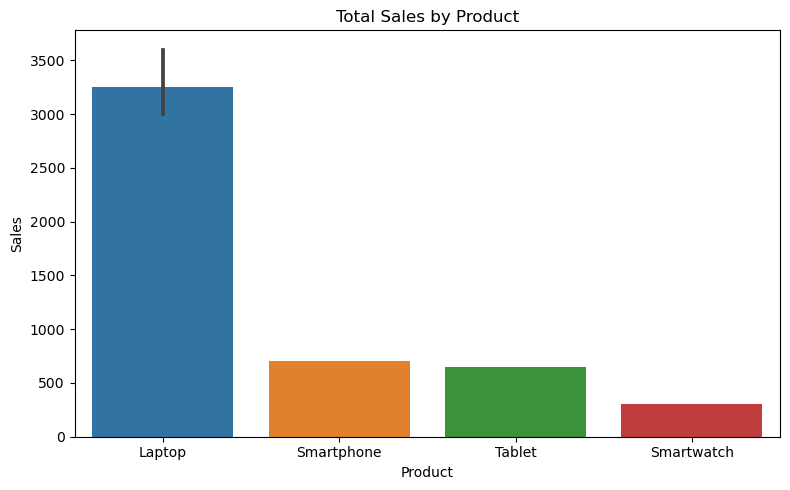

In [11]:
# Seaborn Bar Plot

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Product",
    y="Sales",
    estimator=np.sum
)

plt.title("Total Sales by Product")
plt.tight_layout()
plt.show()


# Plotly Line Chart for Sales Trend

fig = px.line(
    df.sort_values("Sales"),
    x="Product",
    y="Sales",
    color="Region",
    title="Sales Trend by Region"
)

fig.show()